# Kaggle Playground Series S5E5 - Calorie Prediction

## Approach

My approach to predicting calories burned during exercise combined physiological calculations with data-driven feature engineering and machine learning. The core idea was to estimate the Basal Metabolic Rate (BMR) using standard and Mifflin-St Jeor equations, scale it to a per-minute rate, and augment it with an exercise intensity factor derived from features like heart rate and body temperature. This approach aimed to capture both baseline metabolic expenditure and additional calories burned due to physical activity.

To enhance the model’s predictive power, I created a calories-per-minute lookup table based on the training data, aggregated by `Duration`, `Age_Group`, and `Sex`. To avoid data leakage, I used statistical aggregations (mean, median, standard deviation, and variance) rather than raw values. This table was merged with the training and test datasets to provide context on typical calorie burn rates for specific demographic and exercise duration groups. However, this feature did not yield the anticipated performance improvement, possibly due to its limited ability to capture nuanced interactions.

I engineered additional features to model exercise intensity and physiological interactions, including:
- **BMI and Categorization**: Calculated BMI from height and weight, then categorized it as "Normal" or "Overweight."
- **Heart Rate and Body Temperature Metrics**: Derived `HR_Ratio` (heart rate divided by maximum heart rate, estimated as 220 - Age), `Body_Temp_Diff` (difference from 37°C), and `Body_Temp_Ratio` (body temperature relative to its maximum).
- **Interaction Features**: Created features like `Duration_x_HR_Ratio`, `Duration_x_Body_Temp_Diff`, `Intensity` (HR_Ratio * Body_Temp_Diff^2), and `Age_x_HR_Ratio` to capture complex relationships between exercise duration, intensity, and demographics.
- **Duration-Based Features**: Introduced binary indicators for short (`Duration ≤ 4`) and very short (`Duration = 1`) workouts to address potential non-linear effects in low-duration exercises.

I used a `CatBoostRegressor` with 10-fold StratifiedKFold cross-validation, optimizing for Root Mean Squared Logarithmic Error (RMSLE). The model was trained with 3000 iterations and a learning rate of 0.03, achieving a cross-validation RMSLE of approximately 0.0576 ± 0.0005. Feature importance analysis revealed that `Duration_x_HR_Ratio`, `Duration_x_Heart_Rate`, and `Heart_Rate` were the most influential predictors. Predictions were generated for the test set and saved as a submission file.

## Challenges

The primary challenges in this competition stemmed from accurately predicting calories for extreme duration bins (1 minute and 30 minutes) and the RMSLE metric’s sensitivity to errors in low-calorie predictions. Specific issues included:

1. **Heavy Undersampling in Extreme Duration Bins**:
   - The Exploratory Data Analysis (EDA) revealed that short-duration workouts (1 minute) and long-duration workouts (30 minutes) were underrepresented in the training data. This made it challenging for the model to learn robust patterns for these bins.
   - I attempted to address this by assigning higher weights to these samples in the cross-validation folds, but this had minimal impact. I also experimented with under- and oversampling techniques (e.g., random resampling), but they did not significantly improve performance, likely due to the limited diversity of samples in these bins.

2. **RMSLE’s Sensitivity to Small Errors**:
   - The RMSLE metric heavily penalizes relative errors in low-calorie predictions. For example, for a 1-minute workout, predicting 4 calories when the true value was 1 calorie resulted in an RMSLE exceeding 1.0, significantly inflating the overall error.
   - This issue was particularly pronounced in short-duration workouts, where small absolute errors led to large relative errors. Despite engineering features like `Short_Duration` and `Very_Short_Duration` to capture these cases, the model struggled to generalize effectively.

3. **Limitations of the Calories-Per-Minute Lookup Table**:
   - The lookup table, while theoretically sound, did not improve performance as expected. It may have been too coarse, as it relied on aggregated statistics that failed to account for individual variability in exercise intensity or physiological responses.

## Key Findings

Using SHAP (SHapley Additive Explanations) analysis, I investigated the model’s performance, particularly in Fold 6, which had a higher RMSLE (0.060631). The analysis revealed that the largest errors occurred in short-duration workouts (1–6 minutes), where predictions often deviated significantly from true calorie values (e.g., predicting 20.28 calories when the true value was 175). Key observations include:
- **Feature Importance**: Features like `Duration_x_HR_Ratio`, `Duration_x_Heart_Rate`, and `MET` (Metabolic Equivalent of Task) were critical drivers of predictions, especially for high-error samples.
- **Low-Duration Challenges**: Short-duration samples (Duration ≤ 5) had a mean RMSLE of 0.072963, with extreme cases reaching up to 2.113. These errors were driven by the model’s tendency to over- or under-predict calories in low-duration exercises.
- **Visualization**: SHAP summary plots and force plots highlighted the influence of duration-related features, while RMSLE histograms for low-duration samples showed a wide range of errors, indicating inconsistent performance in this subgroup.

The use of 10 folds (90% training, 10% validation) instead of 5 folds provided more training data per fold (~18,000 vs. ~16,000 samples), which likely helped the model capture patterns in underrepresented bins, but it was insufficient to fully address the short-duration issue.

## Future Improvements

To improve performance, especially for short-duration workouts, I propose the following:
1. **Targeted Oversampling**: Use synthetic data generation (e.g., SMOTE) or collect additional data for 1-minute and 30-minute workouts to better balance the training set.
2. **Custom Loss Function**: Develop a modified loss function that reduces the RMSLE penalty for small absolute errors in low-calorie predictions, potentially combining RMSLE with absolute error metrics.
3. **Non-Linear Modeling for Short Durations**: Introduce a separate model or ensemble for short-duration workouts, possibly using a rule-based approach or a specialized regressor trained on low-duration samples.
4. **Enhanced Feature Engineering**: Incorporate more granular physiological features, such as heart rate variability or exercise type (if available), to better capture intensity in short workouts.
5. **Refine Lookup Table**: Improve the calories-per-minute lookup table by including additional grouping variables (e.g., `Heart_Rate` or `BMI`) or using a more sophisticated interpolation method.

## Conclusion

The model achieved a competitive RMSLE of ~0.05908, driven by robust feature engineering and the `CatBoostRegressor`. However, challenges with short-duration workouts and the RMSLE metric’s sensitivity to small errors limited further improvements. SHAP analysis provided valuable insights into error sources, highlighting the need for targeted strategies to handle underrepresented duration bins. Future work focusing on data augmentation and customized modeling for extreme durations could push the performance closer to the top leaderboard scores.

In [2]:
!pip install kagglehub

# Feature Engineering

In [1]:
import os
import pandas as pd
import numpy as np
import kagglehub
from matplotlib import pyplot as plt
from sklearn.utils import resample

try:
  import catboost
except Exception:
  !pip install catboost
  import catboost

VERSION = 'v10'

playground_series_s5e5_path = 'D:/data/CaloriesPrediction/'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

def calculate_bmi(height_cm, weight_kg):
  height_m = height_cm / 100
  bmi = weight_kg / (height_m ** 2)
  return bmi

def categorize_bmi(bmi):
  if bmi < 24.4:
      return 'Normal'
  else:
      return 'Overweight'

def get_bmr(row):
  if row['Sex_Male']:  # Male
    return 66.5 + (13.75 * row['Weight']) + (5.003 * row['Height']) - (6.75 * row['Age'])
  else:  # Female
    return 655.1 + (9.563 * row['Weight']) + (1.850 * row['Height']) - (4.676 * row['Age'])

def get_bmr_miff(row): # Mifflin-St Jeor Equation
  if row['Sex_Male']:  # Male
      return (10 * row['Weight']) + (6.25 * row['Height']) - (5 * row['Age'])
  else:  # Female
      return (10 * row['Weight']) + (9.563 * row['Height']) - (4.676 * row['Age'])

def encode_categorical(data):
  data['Body_Temp_Diff'] = (data['Body_Temp'] - 37).astype('float32')
  #data['Body_Temp_Class'] = pd.cut(data['Body_Temp_Diff'], bins=[1,3,5])

  data['Age_Group'] = pd.cut(data['Age'], bins=[19.99, 30, 40, 60, 70, 80],
                             labels=['20-30', '31-40', '41-60', '61-70', '71-80'])
  data['Sex'] = (data['Sex'] == 'female').astype('int8')

  data['BMI'] = data.apply(lambda x: calculate_bmi(height_cm=x['Height'], weight_kg=x['Weight']), axis=1)
  data['BMI_Class'] = data['BMI'].apply(categorize_bmi)
  data['BMI_Class'] = pd.Categorical(data['BMI_Class'], categories=[
      'Normal', 'Overweight'
  ])

  return data
    
def build_cal_per_min_table():
    """Build a calories per min table"""
    path = os.path.join(playground_series_s5e5_path, 'train.csv')
    data = pd.read_csv(path)
    
    data['Duration'] = data['Duration'].astype('int8')
    data = encode_categorical(data)
    
    data['Calories_per_Minute'] = (data['Calories'] / data['Duration']).astype('float16')
    
    data = data[data['Calories_per_Minute'] <= 10]
    
    data = data.drop(['id','Age', 'BMI_Class', 'Heart_Rate', 'Body_Temp', 'BMI', "Height", "Weight", 'Calories' ], axis=1)
    
    data = data.groupby(['Duration', 'Age_Group', 'Sex' ])['Calories_per_Minute']\
    .agg( ['mean','std','median','var']).rename(columns={
        #'count': 'Calories_per_Minute_count',
        #'max': 'Calories_per_Minute_max',
        #'min': 'Calories_per_Minute_min',
        'mean': 'Calories_per_Minute_mean',
        'std': 'Calories_per_Minute_std',
        'median': 'Calories_per_Minute_median',
        'var': 'Calories_per_Minute_var'
    })
    return data

def get_data(path, lookup_table, do_resample=False):
    is_train = False
    
    data = pd.read_csv(path)
    
    if 'Calories' in data.columns:
        is_train = True
    
    data['Duration'] = data['Duration'].astype('int8')
    
    if do_resample:
        data = resample(train_data, n_samples=5000, replace=False, random_state=42)
    
    len_before = len(data)
    data = encode_categorical(data)
    data = pd.merge(data, lookup_table, how='left',
                  left_on=['Duration','Sex', 'Age_Group' ],
                  right_on=['Duration','Sex', 'Age_Group' ])
    
    assert(len(data) == len_before)
  
    #data['Estimated_Calories'] = data['Calories_per_Minute'] * data['Duration']
    
    # Sex
    data = pd.get_dummies(data, columns=['Age_Group'], dtype='int8')
    #data['Estimated_Calories'] = (data['Duration'] * np.round(data['Calories_per_Minute_mean'],0)).astype('float32')
    data['Sex_Male'] = (data['Sex'] == 0).astype('int8')
    data['Sex_Female'] = (data['Sex'] == 1).astype('int8')
    #data['BMI_Normalweight'] = (data['BMI_Class'] == 'Normal').astype('int8')
    #data['BMI_Overweight'] = (data['BMI_Class'] == 'Overweight').astype('int8')

    # HR, Body Temp
    data['HR_Max'] = 220 - data['Age']
    data['HR_Ratio'] = (data['Heart_Rate'] / data['HR_Max']).astype('float32')
    data['Body_Temp_Ratio'] = (data['Body_Temp'] / data['Body_Temp'].max()).astype('float16')
    data['Intensity'] = (data['HR_Ratio'] * (data['Body_Temp_Diff'])**2).astype('float32')
    data['BMR'] = data.apply(lambda x: get_bmr(x), axis=1).astype('float32')
    data['BMR_per_Minute'] = ((data['BMR'] / 24) / 60).astype('float32')
    data['Base_Calories'] = data['BMR_per_Minute'] * data['Duration']
    data['Duration_x_Body_Temp_Diff'] = (data['Duration'] * data['Body_Temp_Diff']).astype('float32')
    data['Duration_x_Heart_Rate'] = (data['Duration'] * data['Heart_Rate']).astype('float32')
    data['Duration_x_HR_Ratio'] = (data['Duration'] * data['HR_Ratio']).astype('float32')
    #data['Duration_x_HR_Ratio_Recip'] = np.reciprocal(data['Duration_x_HR_Ratio']).astype('float32')
    data['HR_Ratio_x_Body_Temp_Diff'] = data['HR_Ratio'] * data['Body_Temp_Diff']
    #data['Duration_Recip'] = (1 / data['Duration']).astype('float32')
    data['Log_Duration'] = np.log1p(data['Duration']).astype('float32')
    data['Very_Short_Duration'] = (data['Duration'] == 1).astype('int8')
    data['Short_Duration'] = ((data['Duration'] > 1) & (data['Duration'] < 5)).astype('int8')
    return data


df_cal_per_min = build_cal_per_min_table()
print(df_cal_per_min)
train_data = get_data(os.path.join(playground_series_s5e5_path, 'train.csv'), df_cal_per_min, False)
print(train_data)
test_data = get_data(os.path.join(playground_series_s5e5_path, 'test.csv'), df_cal_per_min, False)
test_data

train_data.head()

C:\Users\ADMIN\.conda\envs\cvenv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_23116\2308136151.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = data.groupby(['Duration', 'Age_Group', 'Sex' ])['Calories_per_Minute']\


,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Body_Temp_Diff,BMI,BMI_Class,Calories_per_Minute_mean,Calories_per_Minute_std,Calories_per_Minute_median,Calories_per_Minute_var,Age_Group_20-30,Age_Group_31-40,Age_Group_41-60,Age_Group_61-70,Age_Group_71-80,Sex_Male,Sex_Female,HR_Max,HR_Ratio,Body_Temp_Ratio,Intensity,BMR,BMR_per_Minute,Base_Calories,Duration_x_Body_Temp_Diff,Duration_x_Heart_Rate,Duration_x_HR_Ratio,HR_Ratio_x_Body_Temp_Diff,Log_Duration,Very_Short_Duration,Short_Duration
0,0,0,36,189.0,82.0,26,101.0,41.0,150.0,4.0,22.955684,Normal,6.405137,0.729507,6.347656,0.532181,0,1,0,0,0,1,0,184,0.548913,0.987793,8.782609,1896.567017,1.317060,34.243572,104.0,2626.0,14.271740,2.195652,3.294922,0,0
1,1,1,64,163.0,60.0,8,85.0,39.7,34.0,2.7,22.582709,Normal,4.780476,0.519496,4.750000,0.269876,0,0,0,1,0,0,1,156,0.544872,0.956543,3.972116,1231.166016,0.854976,6.839811,21.6,680.0,4.358974,1.471154,2.197266,0,0
2,2,1,51,161.0,64.0,7,84.0,39.8,29.0,2.8,24.690405,Overweight,4.381793,0.505973,4.429688,0.256009,0,0,1,0,0,0,1,169,0.497041,0.958984,3.896805,1326.505981,0.921185,6.448293,19.6,588.0,3.479290,1.391716,2.080078,0,0
3,3,0,20,192.0,90.0,25,105.0,40.7,140.0,3.7,24.414062,Overweight,5.648929,0.706470,5.601562,0.499100,1,0,0,0,0,1,0,200,0.525000,0.980957,7.187250,2129.575928,1.478872,36.971806,92.5,2625.0,13.124999,1.942500,3.257812,0,0
4,4,1,38,166.0,61.0,25,102.0,40.6,146.0,3.6,22.136740,Normal,6.130155,0.501410,6.121094,0.251412,0,1,0,0,0,0,1,182,0.560440,0.978516,7.263297,1367.854980,0.949899,23.747482,90.0,2550.0,14.010990,2.017582,3.257812,0,0


# Models

## Linear Regression

Fold 1:
  Training indices: [     0      1      3 ... 749995 749996 749998]
  Test indices: [     2      6      7 ... 749991 749997 749999]
  RMSLE: 0.0725
Fold 2:
  Training indices: [     1      2      3 ... 749997 749998 749999]
  Test indices: [     0      4     10 ... 749974 749983 749985]
  RMSLE: 0.0719
Fold 3:
  Training indices: [     0      2      4 ... 749991 749997 749999]
  Test indices: [     1      3      5 ... 749995 749996 749998]
  RMSLE: 0.0721

Average RMSLE: 0.0722 (±0.0002)
Slope (for first feature): 63912816.58
Intercept: -32257779.20


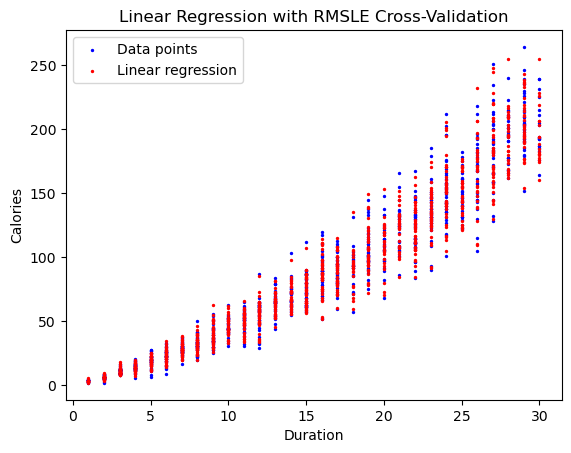

Submission file 'submission_linear_regression_v1.csv' created!


In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt


def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min=0, a_max=None)
    y_true = np.clip(y_true, a_min=0, a_max=None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))


X = train_data.drop(['id',  'Calories'], axis=1)
X_test = test_data.drop(['id'], axis=1)
y = train_data['Calories']
y_log = np.log1p(y)  # Log-transform target for training


numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
features = numeric_features + categorical_features


X = X[numeric_features]
X_test = X_test[numeric_features]


model = LinearRegression()

# Set up 3-fold cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Store scores and test predictions
scores = []
fold = 1
predictions = np.zeros(len(X_test))

# Perform cross-validation
for train_idx, test_idx in cv.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_val = y_log.iloc[train_idx], y_log.iloc[test_idx]

    # Train model on training fold
    model.fit(X_train, y_train)

    # Predict on validation fold (log scale)
    y_pred_val = model.predict(X_val)

    # Calculate RMSLE on original scale
    y_val_orig = np.expm1(y_val)  # Convert back to original scale
    y_pred_val_orig = np.expm1(y_pred_val)
    fold_score = rmsle(y_val_orig, y_pred_val_orig)
    scores.append(fold_score)

    print(f'Fold {fold}:')
    print(f'  Training indices: {train_idx}')
    print(f'  Test indices: {test_idx}')
    print(f'  RMSLE: {fold_score:.4f}')

    # Test predictions (in log scale, then convert back)
    predictions += np.expm1(model.predict(X_test)) / 3  # Use n_splits=3
    fold += 1

# Print average and standard deviation of RMSLE
print(f'\nAverage RMSLE: {np.mean(scores):.4f} (±{np.std(scores):.4f})')

# Train the model on all data
model.fit(X, y_log)  # Train on log-transformed target

# Make predictions
y_pred = np.expm1(model.predict(X))  # Convert back to original scale
y_pred_test = np.expm1(model.predict(X_test))

# Print coefficients
print(f'Slope (for first feature): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


plt.scatter(X['Duration'][:1000], y[:1000], color='blue', label='Data points', s=2)
plt.scatter(X['Duration'][:1000], y_pred[:1000], color='red', label='Linear regression', s=2)
plt.xlabel('Duration')
plt.ylabel('Calories')
plt.title('Linear Regression with RMSLE Cross-Validation')
plt.legend()
plt.show()

# Save submission
submission = pd.DataFrame({'id': test_data['id'], 'Calories': predictions})
submission_file = 'submission_linear_regression_v1.csv'  # Define VERSION explicitly
submission.to_csv(submission_file, index=False)
print(f"Submission file '{submission_file}' created!")

## Catboost with Weights for Low Durations 

0:	learn: 1.1673291	test: 1.0441847	best: 1.0441847 (0)	total: 15s	remaining: 12h 30m 22s
100:	learn: 0.1073110	test: 0.0877123	best: 0.0877123 (100)	total: 16.2s	remaining: 7m 44s
200:	learn: 0.0830848	test: 0.0626204	best: 0.0626204 (200)	total: 17.4s	remaining: 4m 1s
300:	learn: 0.0812185	test: 0.0615239	best: 0.0615239 (300)	total: 18.5s	remaining: 2m 46s
400:	learn: 0.0799172	test: 0.0611439	best: 0.0611439 (400)	total: 19.7s	remaining: 2m 7s
500:	learn: 0.0788693	test: 0.0608724	best: 0.0608724 (500)	total: 20.9s	remaining: 1m 44s
600:	learn: 0.0779269	test: 0.0607152	best: 0.0607152 (600)	total: 22.1s	remaining: 1m 28s
700:	learn: 0.0771326	test: 0.0606076	best: 0.0606068 (692)	total: 23.3s	remaining: 1m 16s
800:	learn: 0.0764202	test: 0.0605343	best: 0.0605343 (800)	total: 24.5s	remaining: 1m 7s
900:	learn: 0.0757351	test: 0.0604685	best: 0.0604685 (900)	total: 25.7s	remaining: 59.8s
1000:	learn: 0.0750652	test: 0.0604157	best: 0.0604157 (1000)	total: 26.9s	remaining: 53.7s
110

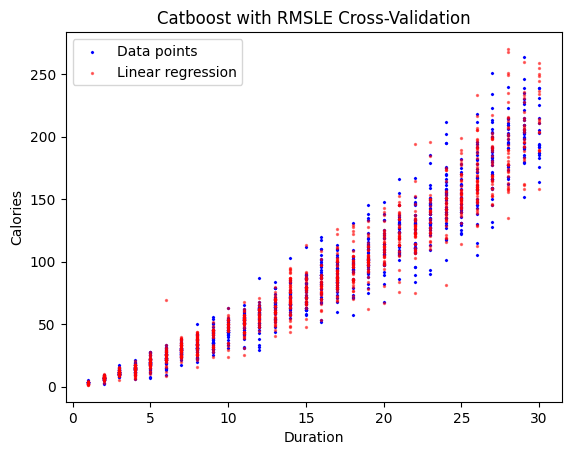

In [3]:
import tqdm
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error
import os
import datetime

drop_columns = ['Height', 'Sex']
# Prepare data
X = train_data.drop(['id', 'Calories'] + drop_columns, axis=1)
X_test = test_data.drop(['id'] + drop_columns, axis=1)
y = train_data['Calories']
y_log = np.log1p(y)
num_folds = 10

# Define features
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
features = numeric_features + categorical_features

X = X[numeric_features]
X_test = X_test[numeric_features]

skf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

cb_params = {
    'iterations': 3000,
    'depth': 10,
    'learning_rate': 0.03,
    'l2_leaf_reg': 2,
    'bagging_temperature': .01,
    'random_seed': 42,
    'task_type': 'GPU',
    'devices': '0',
    'verbose': 100,
    'early_stopping_rounds':50,
    'task_type': 'GPU',
    'devices': '0',
}

predictions = np.zeros(len(X_test))
cv_scores = []

catboost_models = []
X_val_splits = []
y_val_splits = []

# Train and predict with CV
# Train and predict with CV
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]
    #catboost = CatBoostRegressor(**cb_params)
    model = CatBoostRegressor(**cb_params)
    # Initialize Pool

    weights = np.ones(len(X_train))
    weights[X_train['Duration'] <= 4] *= 3.5
    weights[X_train['Age'] <= 30] *= 2
    weights[X_train['Sex_Male'] == 1] *= 1.5  

    train_pool = Pool(X_train, y_train, weight=weights)
    test_pool = Pool(X_val)

    model.fit(train_pool, eval_set=(X_val, y_val), use_best_model=True)

    # Compute validation RMSLE
    val_pred = np.expm1(model.predict(test_pool))
    val_pred = np.clip(val_pred, 1, 500)

    rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_val), val_pred))
    cv_scores.append(rmsle)
    cb_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

    print(f"Fold {fold} RMSLE: {rmsle:.6f}\n")
    print(f"Fold {fold} Top 10 Feature Importances:\n{cb_importances}\n")
    print(f"Fold {fold} Validation Set Calories:")
    print(f"{np.expm1(y_val).describe()}\n")
    print(f'CV distribution:\n{pd.cut(np.expm1(y_val), [0, 10, 50, 100, 200], right=False).value_counts()}\n')

    # Test predictions using X_test (not test_pool)
    test_pool_full = Pool(X_test)  # Create a Pool for the full test set
    test_pred = np.expm1(model.predict(test_pool_full))  # Predict on X_test
    predictions += test_pred / num_folds

    # Collect fold artifacts for SHAP
    catboost_models.append(model)
    X_val_splits.append(X_val)
    y_val_splits.append(y_val)

# Print CV results
mean_cv_score = np.mean(cv_scores)
std_cv_score = np.std(cv_scores)
print(f"CatBoost CV RMSLE: {mean_cv_score:.6f} ± {std_cv_score:.6f}")

# Save submission
submission = pd.DataFrame({'id': test_data['id'], 'Calories': predictions})
submission_file = f'submission.csv'
submission.to_csv(submission_file, index=False)
print(f"Submission file '{submission_file}' created!")

plt.scatter(X['Duration'][:1000], y[:1000], color='blue', marker='x', label='Data points', s=2)
plt.scatter(X_test['Duration'][:1000], predictions[:1000], color='red', label='Linear regression', s=2, alpha=0.5)
plt.xlabel('Duration')
plt.ylabel('Calories')
plt.title('Catboost with RMSLE Cross-Validation')
plt.legend()
plt.show()

## XGBoost

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, DMatrix, train
import os
import datetime

# Custom RMSLE evaluation metric for XGBoost
def rmsle_metric(y_true, y_pred):
    y_true_exp = np.expm1(y_true)
    y_pred_exp = np.clip(np.expm1(y_pred), a_min=0, a_max=None)  # Avoid negative values
    log_true = np.log1p(y_true_exp)
    log_pred = np.log1p(y_pred_exp)
    rmsle = np.sqrt(np.mean((log_true - log_pred) ** 2))
    return 'rmsle', rmsle, False  # False: lower is better

# Define RMSLE computation functions (no clipping, as requested)
def compute_rmsle(y_true, y_pred):
    y_true_exp = np.expm1(y_true)
    y_pred_exp = np.expm1(y_pred)
    log_true = np.log1p(y_true_exp)
    log_pred = np.log1p(y_pred_exp)
    rmsle = np.sqrt(np.mean((log_true - log_pred) ** 2))
    assert np.isfinite(rmsle), "Non-finite RMSLE detected"
    return rmsle

def compute_rmsle_per_sample(y_true, y_pred):
    y_true_exp = np.expm1(y_true)
    y_pred_exp = np.expm1(y_pred)
    log_true = np.log1p(y_true_exp)
    log_pred = np.log1p(y_pred_exp)
    return np.sqrt((log_true - log_pred) ** 2)


X = train_data.drop(['id', 'Calories'], axis=1)
numeric_features = X.select_dtypes(include=np.number).columns
print(f'numeric features: {numeric_features}')

# Prepare data

X = X[numeric_features]
X_test = test_data[numeric_features]

y = train_data['Calories']
y_log = np.log1p(y)

# XGBoost parameters
xgb_params = {
    'n_estimators': 3000,
    'learning_rate': 0.02,
    'max_depth': 10,
    'reg_lambda': 1.0,
    'subsample': 0.9,
    'colsample_bytree':0.7,
    'gamma': .01,
    'max_delta_step':2,
    'tree_method': 'gpu_hist',
    'device': 'cuda',
    'early_stopping_rounds': 100,
    'random_state': 42,
    'verbosity': 2
}

# K-fold CV
num_folds = 10
skf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_rmsles = []
oof_xgboost = np.zeros(len(X))
test_predictions = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\nTraining Fold {fold}...")

    # Split data
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Train XGBoost
    dtrain = DMatrix(X_train, label=y_train)
    dval = DMatrix(X_val, label=y_val)

    xgb_model = train(
        xgb_params,
        dtrain,
        num_boost_round=1500,
        evals=[(dval, 'eval')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    # OOF predictions
    xgb_pred = xgb_model.predict(DMatrix(X_val))
    oof_xgboost[val_idx] = xgb_pred

    fold_rmsle = compute_rmsle(y_val, xgb_pred)
    fold_rmsles.append(fold_rmsle)
    print(f"Fold {fold} RMSLE: {fold_rmsle:.6f}")

    # Test predictions
    dtest = DMatrix(X_test)
    test_pred = xgb_model.predict(DMatrix(X_test))
    test_predictions += test_pred / num_folds

# Compute and log overall RMSLE
mean_rmsle = np.mean(fold_rmsles)
std_rmsle = np.std(fold_rmsles)
print(f"\nMean RMSLE: {mean_rmsle:.6f} ± {std_rmsle:.6f}")

# Save submission
submission = pd.DataFrame({
    'id': test_data['id'],
    'Calories': np.expm1(test_predictions)  # Convert back from log
})
submission_file = f'submission_xgboost_{VERSION}.csv'
submission.to_csv(submission_file, index=False)
print(f"Submission file '{submission_file}' created!")

numeric features: Index(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'Body_Temp_Diff', 'BMI', 'Calories_per_Minute_mean',
       'Calories_per_Minute_std', 'Calories_per_Minute_median',
       'Calories_per_Minute_var', 'Age_Group_20-30', 'Age_Group_31-40',
       'Age_Group_41-60', 'Age_Group_61-70', 'Age_Group_71-80', 'Sex_Male',
       'Sex_Female', 'HR_Max', 'HR_Ratio', 'Body_Temp_Ratio', 'Intensity',
       'BMR', 'BMR_per_Minute', 'Base_Calories', 'Duration_x_Body_Temp_Diff',
       'Duration_x_Heart_Rate', 'Duration_x_HR_Ratio',
       'HR_Ratio_x_Body_Temp_Diff', 'Log_Duration', 'Very_Short_Duration',
       'Short_Duration'],
      dtype='object')

Training Fold 1...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:59:43] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:59:43] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "early_stopping_rounds", "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[01:59:43] INFO: /workspace/src/data/simple_dmatrix.cc:137: Generating new Ellpack page.
[0]	eval-rmse:0.94627
[100]	eval-rmse:0.14215
[200]	eval-rmse:0.06324
[300]	eval-rmse:0.06059
[400]	eval-rmse:0.06046
[500]	eval-rmse:0.06044
[524]	eval-rmse:0.06045


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [01:59:54] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Fold 1 RMSLE: 0.060448

Training Fold 2...
[01:59:55] INFO: /workspace/src/data/simple_dmatrix.cc:137: Generating new Ellpack page.
[0]	eval-rmse:0.94248


...


Training Fold 10...
[02:01:27] INFO: /workspace/src/data/simple_dmatrix.cc:137: Generating new Ellpack page.
[0]	eval-rmse:0.94863


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [02:01:27] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [02:01:27] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "early_stopping_rounds", "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


[100]	eval-rmse:0.14171
[200]	eval-rmse:0.06186
[300]	eval-rmse:0.05916
[400]	eval-rmse:0.05904
[457]	eval-rmse:0.05904
Fold 10 RMSLE: 0.059041


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [02:01:37] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)



Mean RMSLE: 0.059762 ± 0.000967
Submission file 'submission_xgboost_v10.csv' created!


# EDA 

### 1st and 30th Duration Bins :(

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


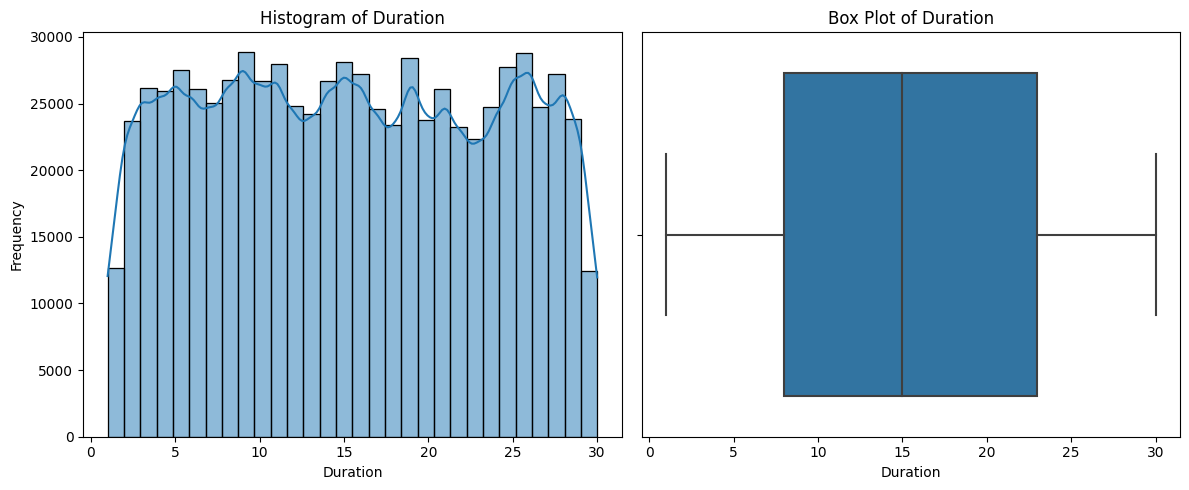


Statistics for Duration:


In [5]:
from matplotlib import pyplot as plt
import seaborn as sns

numerical_features = ["Duration"]

for feature in numerical_features:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(train_data[feature], kde=True, bins=30)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_data[feature])
    plt.title(f"Box Plot of {feature}")

    plt.tight_layout()
    plt.show()

    print(f"\nStatistics for {feature}:")


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Axes: xlabel='Duration', ylabel='Calories'>

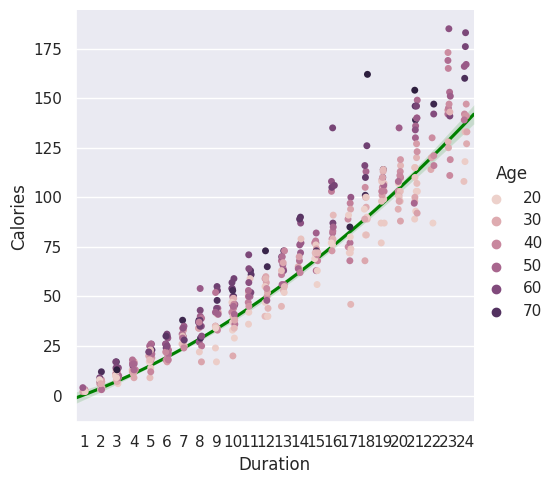

In [6]:
from sklearn.utils import resample
import seaborn as sns
sns.set_theme()
data = resample(train_data, n_samples=500)
data = data[data['Duration'] < 25]
# Plot sepal width as a function of sepal_length across days
g = sns.catplot(
    data=data, hue='Age',
    x="Duration", y="Calories"
)
sns.regplot(
    data=data, x="Duration", y="Calories",
    scatter=False, truncate=False, order=2, color="green",
)


# Use more informative axis labels than are provided by default

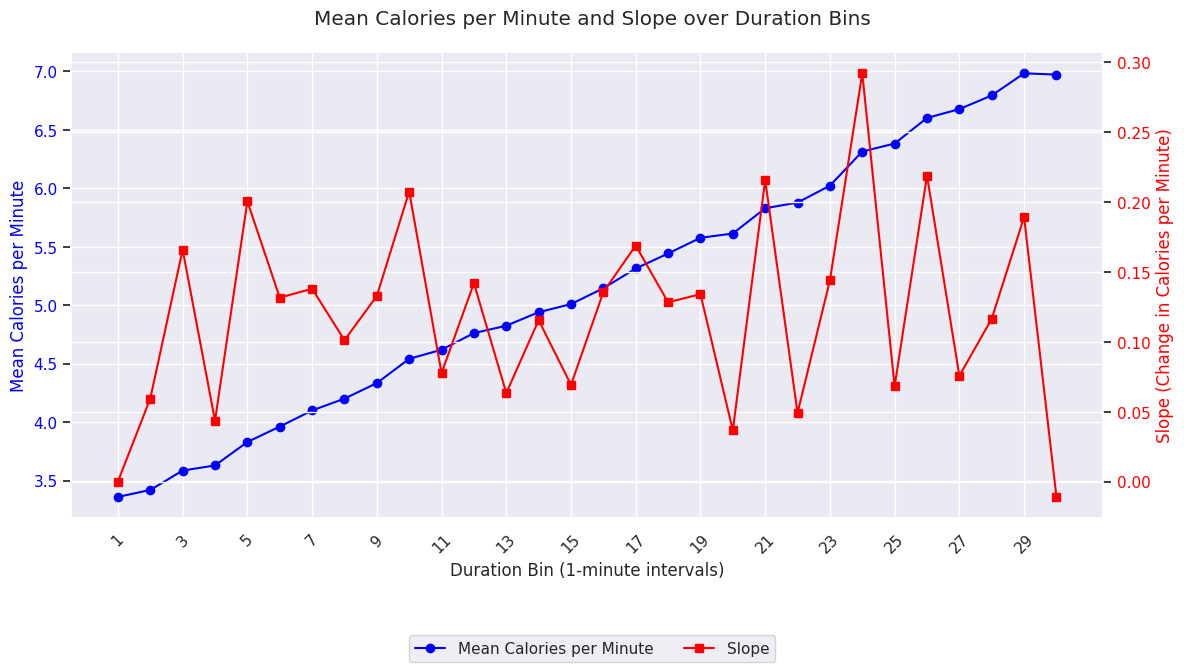

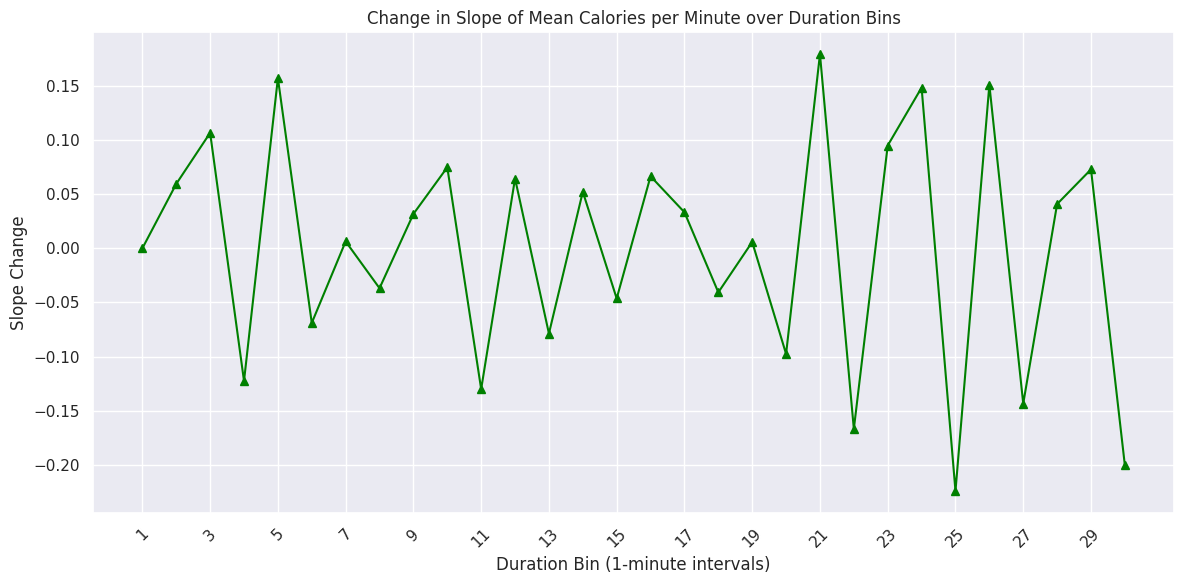

Results saved to 'calories_per_duration_slope.csv'

Result DataFrame:
              Mean Calories per Minute     Slope  Slope Change
Duration_bin                                                  
1                             3.360215  0.000000      0.000000
2                             3.419646  0.059431      0.059431
3                             3.585643  0.165997      0.106566
4                             3.629183  0.043539     -0.122458
5                             3.829738  0.200556      0.157016
6                             3.961401  0.131663     -0.068893
7                             4.099415  0.138013      0.006350
8                             4.200590  0.101175     -0.036838
9                             4.333460  0.132870      0.031695
10                            4.541058  0.207598      0.074728
11                            4.618680  0.077622     -0.129976
12                            4.760693  0.142013      0.064391
13                            4.824037  0.063344

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


#  Calculate calories per minute
train_data['Calories_per_minute'] = train_data['Calories'] / train_data['Duration']

# Bin Duration into 30 bins
num_bins = 30
train_data['Duration_bin'] = pd.cut(
    train_data['Duration'],
    bins=num_bins,
    labels=[f'{i+1}' for i in range(num_bins)],
    include_lowest=True
)

# Compute mean calories per minute by Duration bin
mean_by_duration = train_data.groupby('Duration_bin', observed=True)['Calories_per_minute'].mean()

# Calculate slope (first derivative)
slopes = mean_by_duration.diff().fillna(0)  # Difference between consecutive bins
slopes.name = 'Slope'

# Calculate change in slope (second derivative)
slope_changes = slopes.diff().fillna(0)  # Difference of slopes
slope_changes.name = 'Slope Change'

result_df = pd.DataFrame({
    'Mean Calories per Minute': mean_by_duration,
    'Slope': slopes,
    'Slope Change': slope_changes
})

# Plot 1: Mean Calories per Minute and Slope
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(result_df.index, result_df['Mean Calories per Minute'], marker='o', color='blue', label='Mean Calories per Minute')
ax1.set_xlabel('Duration Bin (1-minute intervals)')
ax1.set_ylabel('Mean Calories per Minute', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(range(0, len(result_df.index), 2))
ax1.set_xticklabels(result_df.index[::2], rotation=45)
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(result_df.index, result_df['Slope'], marker='s', color='red', label='Slope')
ax2.set_ylabel('Slope (Change in Calories per Minute)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle('Mean Calories per Minute and Slope over Duration Bins')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.tight_layout()
plt.show()

# Plot 2: Slope Change
plt.figure(figsize=(12, 6))
plt.plot(result_df.index, result_df['Slope Change'], marker='^', color='green')
plt.title('Change in Slope of Mean Calories per Minute over Duration Bins')
plt.xlabel('Duration Bin (1-minute intervals)')
plt.ylabel('Slope Change')
plt.xticks(range(0, len(result_df.index), 2), result_df.index[::2], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Save results
result_df.to_csv('calories_per_duration_slope.csv')
print("Results saved to 'calories_per_duration_slope.csv'")
print("\nResult DataFrame:")
print(result_df)

if 'Calories_per_minute' in train_data.columns:
    train_data.drop('Calories_per_minute', axis=1)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


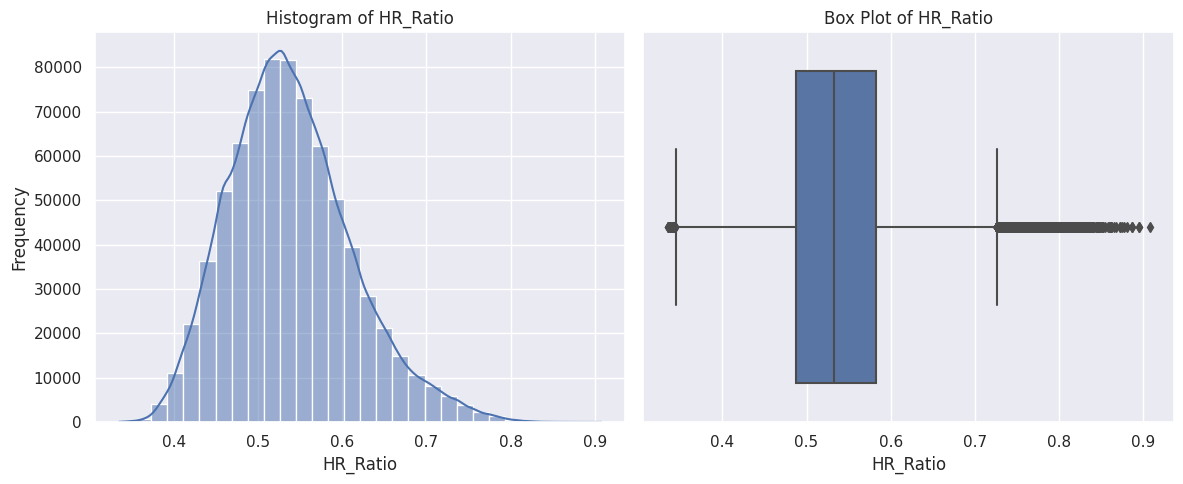


Statistics for HR_Ratio:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


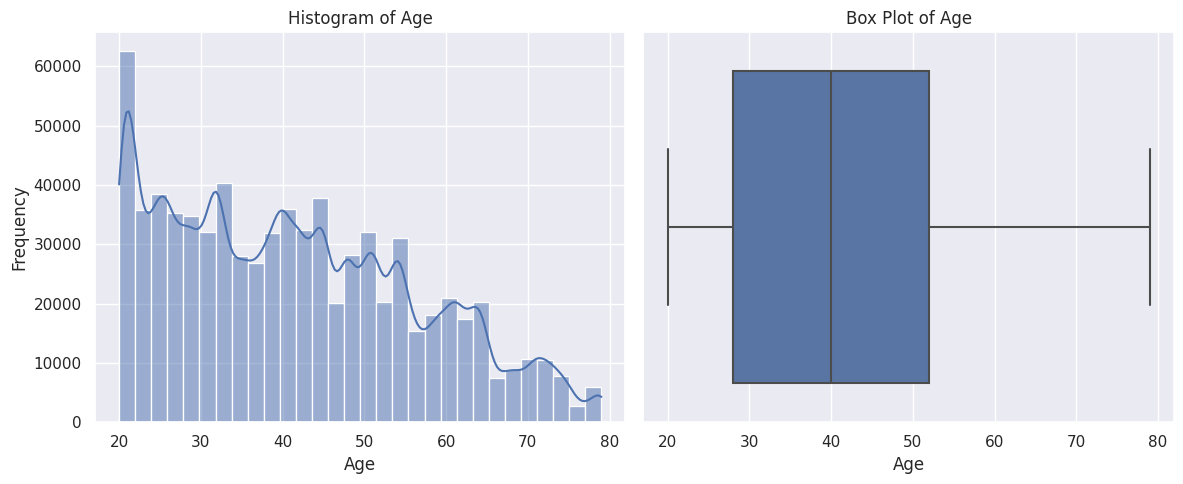


Statistics for Age:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


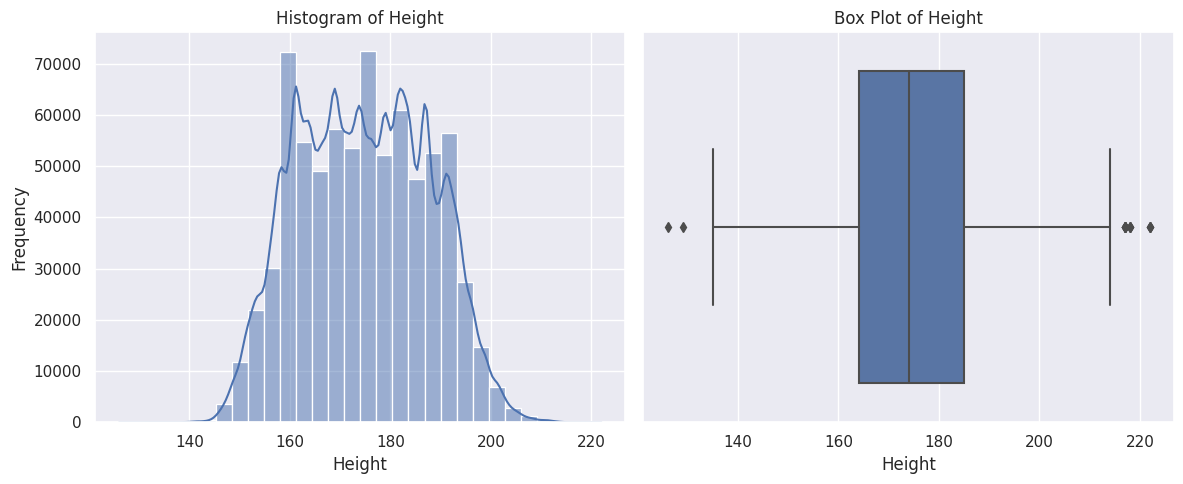


Statistics for Height:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


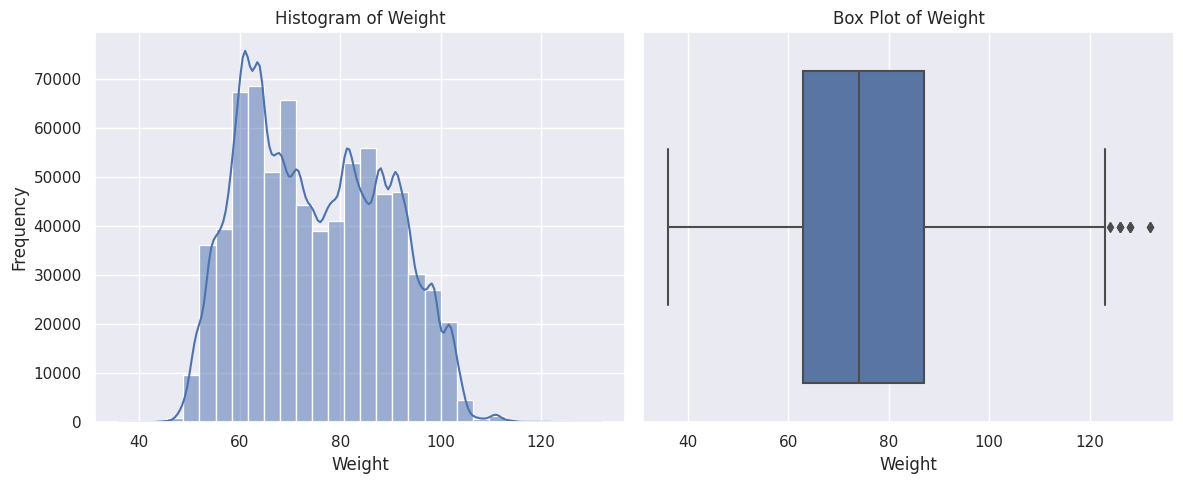


Statistics for Weight:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


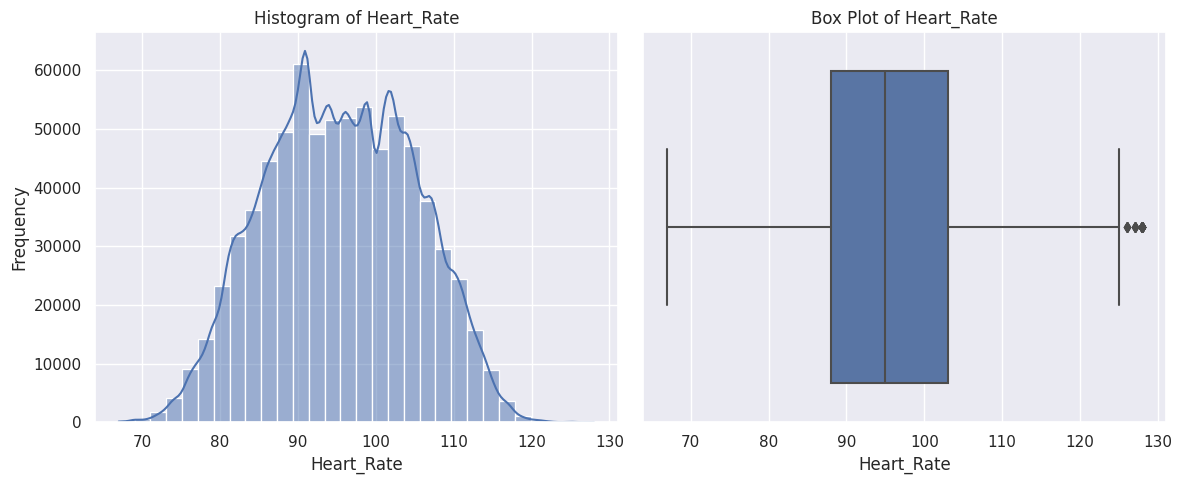


Statistics for Heart_Rate:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


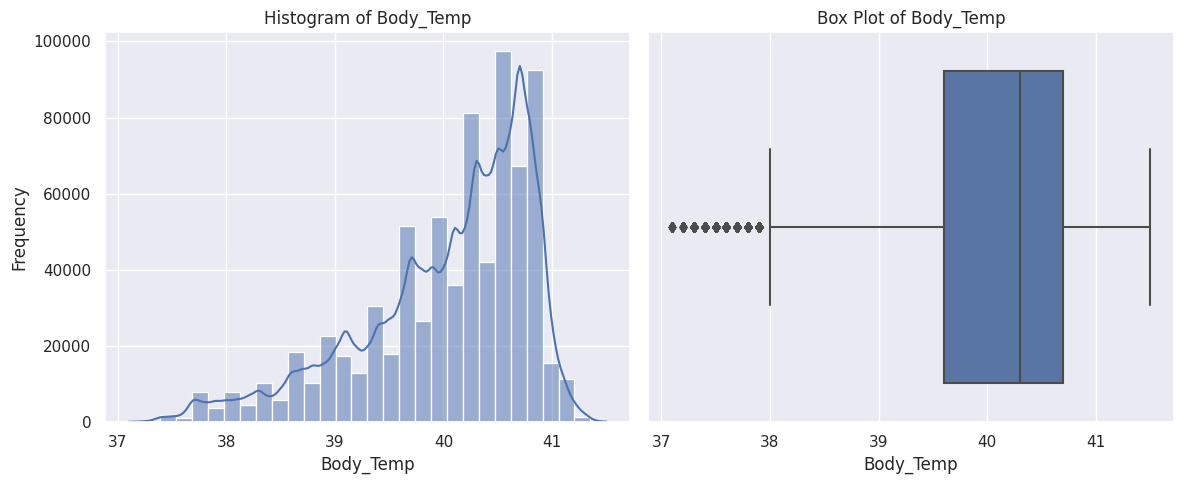


Statistics for Body_Temp:


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


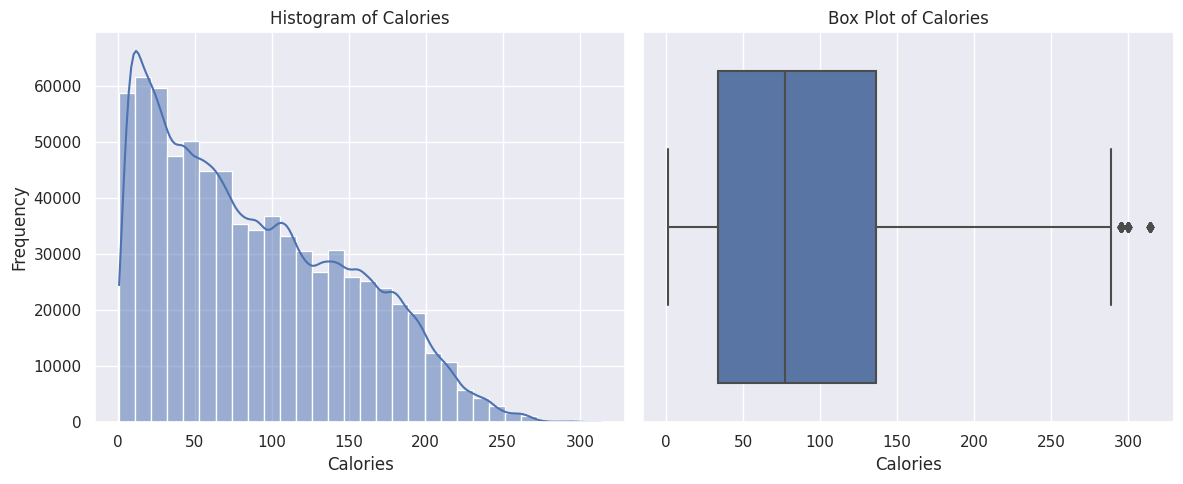


Statistics for Calories:


In [8]:
import seaborn as sns

numerical_features = ["HR_Ratio", "Age","Height","Weight",
                      "Heart_Rate","Body_Temp","Calories"]

for feature in numerical_features:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(train_data[feature], kde=True, bins=30)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_data[feature])
    plt.title(f"Box Plot of {feature}")

    plt.tight_layout()
    plt.show()

    print(f"\nStatistics for {feature}:")